# Importing the Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# Data Collection and Processing

In [ ]:
gold_data = pd.read_csv('gld_price_data.csv')

In [ ]:
gold_data

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.1800,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.2850,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.1670,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.0530,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.5900,1.557099
...,...,...,...,...,...,...
2285,5/8/2018,2671.919922,124.589996,14.060000,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.370000,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.410000,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.380000,15.5600,1.193118


In [ ]:
gold_data.shape

(2290, 6)

In [ ]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [ ]:
gold_data.isnull().sum().sum()

0

In [ ]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [ ]:
gold_data_drop_col = gold_data.drop(['Date'],axis=1)
gold_data_drop_col

,SPX,GLD,USO,SLV,EUR/USD
0,1447.160034,84.860001,78.470001,15.1800,1.471692
1,1447.160034,85.570000,78.370003,15.2850,1.474491
2,1411.630005,85.129997,77.309998,15.1670,1.475492
3,1416.180054,84.769997,75.500000,15.0530,1.468299
4,1390.189941,86.779999,76.059998,15.5900,1.557099
...,...,...,...,...,...
2285,2671.919922,124.589996,14.060000,15.5100,1.186789
2286,2697.790039,124.330002,14.370000,15.5300,1.184722
2287,2723.070068,125.180000,14.410000,15.7400,1.191753
2288,2730.129883,124.489998,14.380000,15.5600,1.193118


In [ ]:
#mean =gold_data_drop_col['SPX'].mean()
#std = gold_data_drop_col['SPX'].std()
#gold_data_drop_col['Z-score'] = (gold_data_drop_col['SPX'] - mean)/std
#threshold = 5
#df_no_outliers = gold_data_drop_col[(gold_data_drop_col['Z-score'] <= threshold) & (gold_data_drop_col['Z-score'] >= -threshold)]

#plt.figure(figsize = (8,8))
#sns.boxplot(df_no_outliers)
#plt.title('Box plot for outlier detection')
#plt.show()

# Correlation:
1. Positive Correlation
2. Negative Correlation

In [ ]:
correlation = gold_data_drop_col.corr()

<Axes: >

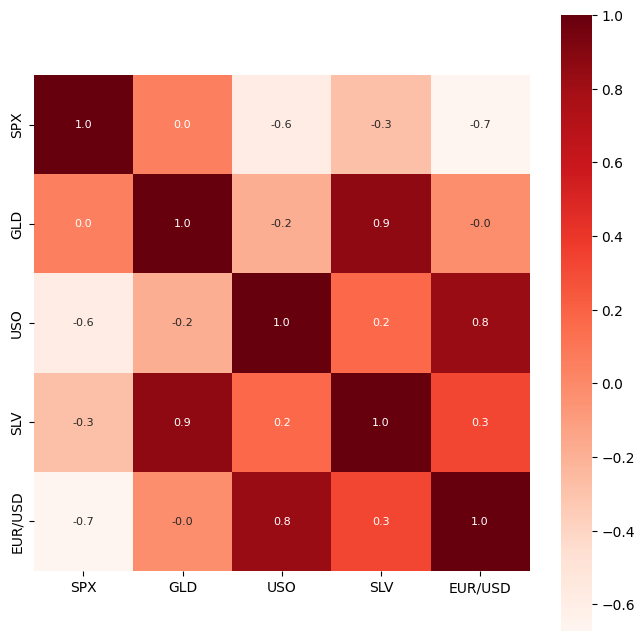

In [ ]:
plt.figure(figsize = (8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Reds')

In [ ]:
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


<ipython-input-13-9cc5f124eed5>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data_drop_col['GLD'],color='green')


<Axes: xlabel='GLD', ylabel='Density'>

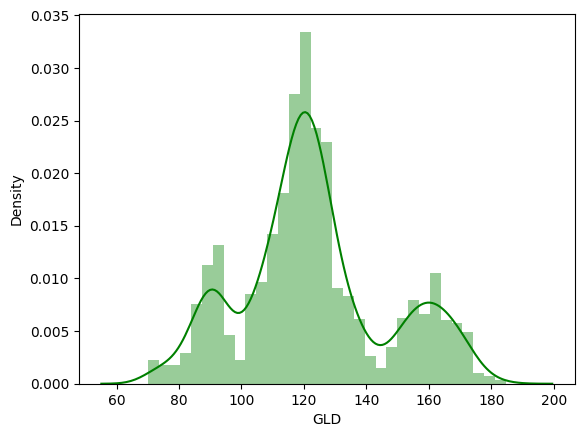

In [ ]:
sns.distplot(gold_data_drop_col['GLD'],color='green')

# Splitting the Features and Target

In [ ]:
X = gold_data_drop_col.drop(['GLD'],axis=1)
Y = gold_data_drop_col['GLD']

In [ ]:
X

,SPX,USO,SLV,EUR/USD
0,1447.160034,78.470001,15.1800,1.471692
1,1447.160034,78.370003,15.2850,1.474491
2,1411.630005,77.309998,15.1670,1.475492
3,1416.180054,75.500000,15.0530,1.468299
4,1390.189941,76.059998,15.5900,1.557099
...,...,...,...,...
2285,2671.919922,14.060000,15.5100,1.186789
2286,2697.790039,14.370000,15.5300,1.184722
2287,2723.070068,14.410000,15.7400,1.191753
2288,2730.129883,14.380000,15.5600,1.193118


In [ ]:
Y

,GLD
0,84.860001
1,85.570000
2,85.129997
3,84.769997
4,86.779999
...,...
2285,124.589996
2286,124.330002
2287,125.180000
2288,124.489998


# Splitting into Training data and Test Data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Linear Regression

In [ ]:
Linear_model = LinearRegression()
Linear_model.fit(X_train_scaled,Y_train)

LinearRegression()

In [ ]:
Y_pre = Linear_model.predict(X_test_scaled)
error_score = r2_score(Y_test, Y_pre)
print("R squared error : ", error_score)


R squared error :  0.8657886565869237


# Model Training: Random Forest Regressor


In [ ]:
regressor = RandomForestRegressor(n_estimators=100)

In [ ]:
regressor.fit(X_train_scaled,Y_train)

RandomForestRegressor()

## Model Evaluation

In [ ]:
y_pred_rf = regressor.predict(X_test_scaled)
y_pre

array([168.37879986,  81.8743999 , 116.29930035, 127.63930088,
       120.77780129, 154.77949796, 150.37119884, 126.15110008,
       117.52829869, 125.97430049, 116.7057012 , 171.56030061,
       141.89989796, 167.83319895, 115.06650038, 117.69340087,
       139.70990327, 170.45020164, 159.05870251, 160.41709983,
       155.23670006, 125.42320035, 176.21779919, 156.91960345,
       125.32870029,  93.88009979,  77.58430017, 120.52629967,
       119.15329949, 167.4952995 ,  88.12030067, 125.3899005 ,
        91.22900083, 117.89430013, 121.12879912, 136.18330097,
       115.20030105, 115.5670007 , 147.07239959, 107.16100105,
       104.3145026 ,  87.25379817, 126.48250063, 117.83639966,
       154.62419951, 119.63020009, 108.43079974, 108.03419837,
        93.1251006 , 127.082298  ,  75.76330017, 113.57709924,
       121.38620006, 111.33309908, 118.81219889, 120.5691998 ,
       159.62179897, 168.22640151, 147.06799663,  85.69849838,
        94.45080034,  86.79509916,  90.37469981, 119.04

 R squared error

In [ ]:

error_score = r2_score(Y_test, y_pred_rf)
print("R squared error : ", error_score)

R squared error :  0.9892808372011428


# Gradient Boosting Regresso

In [ ]:
gbr = GradientBoostingRegressor()
gbr.fit(X_train_scaled,Y_train)

GradientBoostingRegressor()

In [ ]:
y_pre_gbr = gbr.predict(X_test_scaled)
r2 = r2_score(Y_test, y_pre_gbr)
print("R squared error : ", r2)


R squared error :  0.9765575827912487


**Best of R2 Score = 0.9890368292785301**

**Random Forest Regressor**


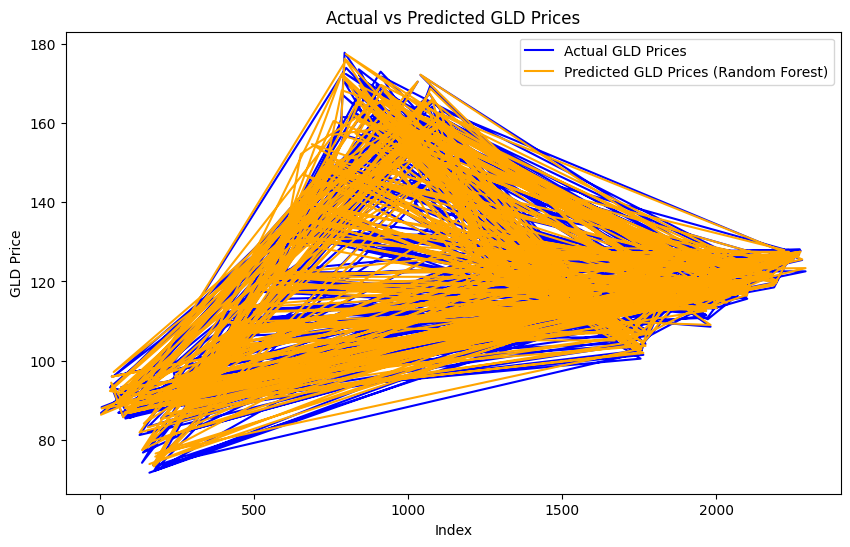

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(Y_test.index, Y_test, label='Actual GLD Prices', color='blue')
plt.plot(Y_test.index, y_pred_rf, label='Predicted GLD Prices (Random Forest)', color='orange')
plt.title('Actual vs Predicted GLD Prices')
plt.xlabel('Index')
plt.ylabel('GLD Price')
plt.legend()
plt.show()

In [ ]:
recent_actual = Y_test.tail(10).mean()
recent_predicted = y_pred_rf[-10:].mean()

print("Recent Actual GLD Price:", recent_actual)
print("Recent Predicted GLD Price:", recent_predicted)

Recent Actual GLD Price: 132.5319992
Recent Predicted GLD Price: 134.26418948299994


**Conclusion**

In this analysis, three regression models were applied to predict GLD prices: Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor. The best model was the Random Forest Regressor, achieving an R-squared (R²) value of **0.9893**, indicating an excellent fit to the data. The recent results showed an actual GLD price of **132.53** and a predicted price of **134.26**, suggesting an expected increase.Therefore, it is expected that GLD prices are likely to go up in the near future.